# Importância de Features e Experimentos Mensais

Este notebook cria diagnósticos replicáveis para a modelagem diária de faturamento bruto por filial.

Objetivos:

1. medir quais features mais impactam o LightGBM, modelo inicial com melhor resultado;
2. comparar diferentes janelas históricas de 2024 para prever cada mês de 2025;
3. salvar as saídas em `Base_Modelagem`, permitindo comparação futura.

Observação: o experimento mensal mede o impacto de janelas históricas de treino. Ele não substitui uma validação temporal completa de produção, mas ajuda a responder se meses específicos do ano anterior carregam sinal útil para prever o mesmo período do ano seguinte.

In [1]:
from pathlib import Path
import json
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)


def encontrar_raiz_projeto(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    candidatos = [inicio, *inicio.parents]

    for candidato in candidatos:
        if (candidato / "Base_Modelagem").exists():
            return candidato

    raise FileNotFoundError(
        "Não foi possível encontrar a raiz do projeto. "
        "Execute primeiro os notebooks 01 e 02 de modelagem."
    )


ROOT = encontrar_raiz_projeto()
BASE_MODELAGEM = ROOT / "Base_Modelagem"

ARQUIVO_BASE_MODELAGEM = BASE_MODELAGEM / "base_modelagem_diaria.parquet"
ARQUIVO_FEATURES_JSON = BASE_MODELAGEM / "features_modelagem.json"
ARQUIVO_IMPORTANCIAS_NATIVAS = BASE_MODELAGEM / "importancias_catboost_lightgbm.parquet"

ARQUIVO_PERMUTATION = BASE_MODELAGEM / "importancia_permutation_lightgbm.parquet"
ARQUIVO_GRUPOS = BASE_MODELAGEM / "importancia_grupos_lightgbm.parquet"
ARQUIVO_SHAP = BASE_MODELAGEM / "importancia_shap_lightgbm.parquet"
ARQUIVO_METRICAS_MESES = BASE_MODELAGEM / "metricas_janelas_mensais.parquet"
ARQUIVO_PREDICOES_MESES = BASE_MODELAGEM / "predicoes_janelas_mensais.parquet"

RANDOM_STATE = 42
N_REPEATS_PERMUTATION = 3
AMOSTRA_SHAP = 1500

PALETA = {
    "azul": "#2563EB",
    "laranja": "#F97316",
    "verde": "#16A34A",
    "vermelho": "#DC2626",
    "cinza": "#4B5563",
    "cinza_claro": "#E5E7EB",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#374151",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.frameon": False,
})


def mostrar_insight(titulo, texto):
    display(Markdown(f"**{titulo}**  \n{texto}"))


def formatar_pct(valor):
    return f"{valor * 100:.2f}%".replace(".", ",")


def formatar_pp(valor):
    return f"{valor:.2f} p.p.".replace(".", ",")

## 1. Carregamento da base oficial

A base usada aqui é a mesma criada no notebook `01_base_modelagem_diaria.ipynb`.

In [2]:
base = pd.read_parquet(ARQUIVO_BASE_MODELAGEM)
metadata_features = json.loads(ARQUIVO_FEATURES_JSON.read_text(encoding="utf-8"))

ALVO = metadata_features["alvo"]
TARGET_TRANSFORMADO = metadata_features["target_transformado"]
FEATURES_CATEGORICAS = metadata_features["features_categoricas"]
FEATURES_NUMERICAS = metadata_features["features_numericas"]
FEATURES_MODELO = metadata_features["features_modelo"]

base["data"] = pd.to_datetime(base["data"])
base["ano_data"] = base["data"].dt.year

for coluna in FEATURES_CATEGORICAS:
    base[coluna] = base[coluna].astype(str).fillna("SEM_INFO")

for coluna in FEATURES_NUMERICAS:
    base[coluna] = pd.to_numeric(base[coluna], errors="coerce").astype("float64").fillna(0)

treino = base[base["conjunto"].eq("treino")].copy()
validacao = base[base["conjunto"].eq("validacao")].copy()
teste = base[base["conjunto"].eq("teste")].copy()

X_train = treino[FEATURES_MODELO].copy()
y_train = treino[TARGET_TRANSFORMADO]
X_val = validacao[FEATURES_MODELO].copy()
y_val = validacao[TARGET_TRANSFORMADO]
X_test = teste[FEATURES_MODELO].copy()
y_test_real = teste[ALVO]

resumo = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "linhas": [len(treino), len(validacao), len(teste)],
    "filiais": [
        treino["codigo_filial"].nunique(),
        validacao["codigo_filial"].nunique(),
        teste["codigo_filial"].nunique(),
    ],
    "data_min": [treino["data"].min(), validacao["data"].min(), teste["data"].min()],
    "data_max": [treino["data"].max(), validacao["data"].max(), teste["data"].max()],
})

display(resumo)
display(pd.DataFrame({
    "grupo": ["categóricas", "numéricas", "total"],
    "qtd": [len(FEATURES_CATEGORICAS), len(FEATURES_NUMERICAS), len(FEATURES_MODELO)],
}))

mostrar_insight(
    "Leitura da base",
    f"A modelagem usa {len(FEATURES_MODELO)} features para prever `{ALVO}` em {teste['codigo_filial'].nunique()} filiais no período de teste."
)

,conjunto,linhas,filiais,data_min,data_max
0,treino,60882,100,2024-01-01,2025-08-31
1,validação,6100,100,2025-09-01,2025-10-31
2,teste,6100,100,2025-11-01,2025-12-31


,grupo,qtd
0,categóricas,12
1,numéricas,40
2,total,52


**Leitura da base**  
A modelagem usa 52 features para prever `faturamento_bruto_dia` em 100 filiais no período de teste.

## 2. Funções reutilizáveis

As métricas e o preparo das variáveis categóricas ficam em funções para o diagnóstico poder ser reexecutado sem ajuste manual.

In [3]:
def desfazer_log(pred_log):
    return np.expm1(pred_log).clip(min=0)


def wape(y_real, y_pred):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominador = np.abs(y_real).sum()
    return np.abs(y_pred - y_real).sum() / denominador if denominador else np.nan


def calcular_metricas(y_real, y_pred, modelo, conjunto, extra=None):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    erro = y_pred - y_real
    linha = {
        "modelo": modelo,
        "conjunto": conjunto,
        "linhas": len(y_real),
        "mae": mean_absolute_error(y_real, y_pred),
        "rmse": mean_squared_error(y_real, y_pred, squared=False),
        "wape": wape(y_real, y_pred),
        "bias_pct": erro.sum() / y_real.sum() if y_real.sum() else np.nan,
        "faturamento_real": y_real.sum(),
        "faturamento_previsto": y_pred.sum(),
    }
    if extra:
        linha.update(extra)
    return linha


def preparar_lightgbm(X, features_categoricas=FEATURES_CATEGORICAS):
    X_lgb = X.copy()
    for coluna in features_categoricas:
        if coluna in X_lgb.columns:
            X_lgb[coluna] = X_lgb[coluna].astype("category")
    return X_lgb


def predizer_lightgbm(modelo, X):
    return desfazer_log(modelo.predict(preparar_lightgbm(X)))

## 3. Treino do LightGBM de referência

Usamos a mesma configuração do notebook oficial de CatBoost/LightGBM. O LightGBM foi escolhido para os diagnósticos por ter sido o melhor modelo inicial no teste.

In [4]:
lightgbm_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

lightgbm_model.fit(
    preparar_lightgbm(X_train),
    y_train,
    eval_set=[(preparar_lightgbm(X_val), y_val)],
    eval_metric="rmse",
    categorical_feature=FEATURES_CATEGORICAS,
    callbacks=[lgb.early_stopping(80, verbose=False)],
)

pred_teste_lgb = predizer_lightgbm(lightgbm_model, X_test)
metricas_referencia = pd.DataFrame([
    calcular_metricas(y_test_real, pred_teste_lgb, "lightgbm", "teste")
])

print("Melhor iteração LightGBM:", lightgbm_model.best_iteration_)
display(metricas_referencia)

wape_ref = metricas_referencia.loc[0, "wape"]
bias_ref = metricas_referencia.loc[0, "bias_pct"]
mostrar_insight(
    "Referência do diagnóstico",
    f"O modelo reproduz o WAPE de teste em {formatar_pct(wape_ref)}. O bias é {formatar_pct(bias_ref)}, indicando subestimação quando negativo."
)

Melhor iteração LightGBM: 442


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,modelo,conjunto,linhas,mae,rmse,wape,bias_pct,faturamento_real,faturamento_previsto
0,lightgbm,teste,6100,17703.654551,35853.365762,0.195539,-0.087312,5.522794e+08,5.040585e+08


**Referência do diagnóstico**  
O modelo reproduz o WAPE de teste em 19,55%. O bias é -8,73%, indicando subestimação quando negativo.

## 4. Importância nativa

A importância nativa é rápida e útil para triagem. Ela mostra quais variáveis o modelo mais usou internamente. Para leitura final, ela deve ser combinada com permutation importance e SHAP.

,modelo,feature,importancia
40,catboost,quantidade_lag_7d,17.676841
43,catboost,share_med_faturamento_lag_7d,14.664653
39,catboost,cupons_lag_7d,13.581440
41,catboost,faturamento_med_lag_7d,8.924960
17,catboost,dia_semana_id,6.950776
22,catboost,eh_feriado_bancario,5.060550
31,catboost,periodo_ordem,4.718530
36,catboost,faturamento_bruto_lag_7d,4.525528
32,catboost,dias_desde_primeira_venda,3.415267
42,catboost,faturamento_n_med_lag_7d,2.593376


,modelo,feature,importancia_gain,importancia_split
41,lightgbm_retreinado,faturamento_med_lag_7d,677683.764429,612
17,lightgbm_retreinado,dia_semana_id,321862.287128,811
31,lightgbm_retreinado,periodo_ordem,290108.911737,1155
43,lightgbm_retreinado,share_med_faturamento_lag_7d,167529.687449,814
23,lightgbm_retreinado,eh_dia_util,63700.396704,393
0,lightgbm_retreinado,codigo_filial,60346.058185,2747
36,lightgbm_retreinado,faturamento_bruto_lag_7d,47253.747032,638
22,lightgbm_retreinado,eh_feriado_bancario,46915.075786,902
44,lightgbm_retreinado,faturamento_bruto_media_movel_7d,40515.033918,1423
32,lightgbm_retreinado,dias_desde_primeira_venda,38752.894330,687


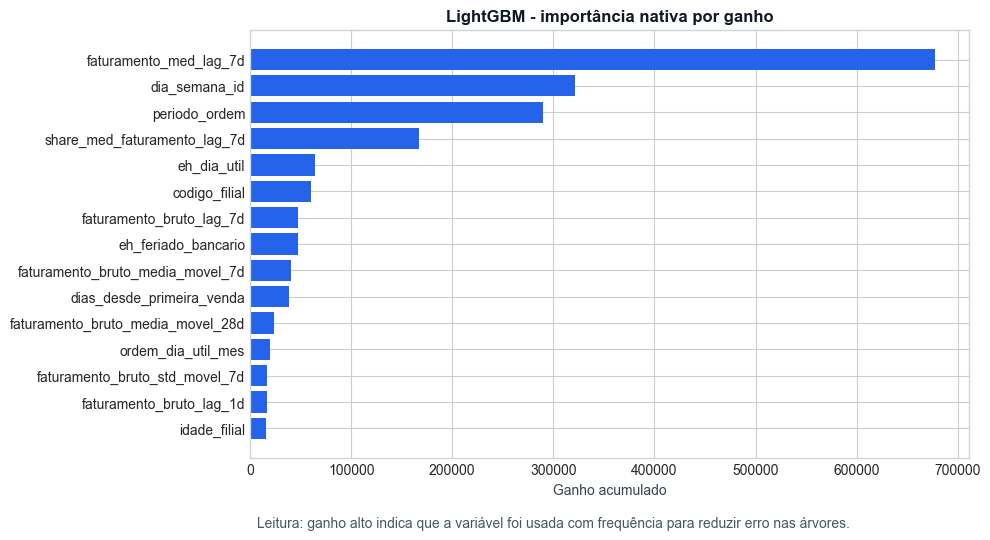

**Insight da importância nativa**  
A feature com maior ganho foi `faturamento_med_lag_7d`. Isso não prova causalidade, mas indica forte uso interno pelo LightGBM.

In [5]:
importancias_nativas = pd.read_parquet(ARQUIVO_IMPORTANCIAS_NATIVAS)

importancias_lgb_gain = pd.DataFrame({
    "modelo": "lightgbm_retreinado",
    "feature": FEATURES_MODELO,
    "importancia_gain": lightgbm_model.booster_.feature_importance(importance_type="gain"),
    "importancia_split": lightgbm_model.booster_.feature_importance(importance_type="split"),
}).sort_values("importancia_gain", ascending=False)

display(importancias_nativas.sort_values(["modelo", "importancia"], ascending=[True, False]).groupby("modelo").head(15))
display(importancias_lgb_gain.head(20))

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = importancias_lgb_gain.head(15).sort_values("importancia_gain")
ax.barh(plot_df["feature"], plot_df["importancia_gain"], color=PALETA["azul"])
ax.set_title("LightGBM - importância nativa por ganho")
ax.set_xlabel("Ganho acumulado")
ax.set_ylabel("")
ax.text(
    0.01,
    -0.16,
    "Leitura: ganho alto indica que a variável foi usada com frequência para reduzir erro nas árvores.",
    transform=ax.transAxes,
    color=PALETA["cinza"],
)
plt.tight_layout()
plt.show()

top_native = importancias_lgb_gain.iloc[0]
mostrar_insight(
    "Insight da importância nativa",
    f"A feature com maior ganho foi `{top_native['feature']}`. Isso não prova causalidade, mas indica forte uso interno pelo LightGBM."
)

## 5. Permutation importance

Este teste mede quanto o WAPE piora quando embaralhamos uma feature no conjunto de teste. Quanto maior o `delta_wape`, maior a dependência do modelo naquela variável.

,feature,wape_base,wape_permutado_medio,wape_permutado_std,delta_wape,delta_wape_pp,n_repeats
0,codigo_filial,0.195539,0.286431,0.001205,0.090892,9.089160,3
1,faturamento_bruto_media_movel_7d,0.195539,0.234413,0.001181,0.038874,3.887362,3
2,eh_dia_util,0.195539,0.226099,0.000734,0.030559,3.055945,3
3,faturamento_bruto_lag_1d,0.195539,0.222131,0.000483,0.026592,2.659218,3
4,semana_ano,0.195539,0.211730,0.000495,0.016191,1.619052,3
5,eh_feriado_bancario,0.195539,0.211267,0.001019,0.015728,1.572811,3
6,faturamento_bruto_media_movel_28d,0.195539,0.206817,0.000521,0.011278,1.127752,3
7,metragem_area_venda,0.195539,0.203524,0.000407,0.007984,0.798442,3
8,dia_semana,0.195539,0.203232,0.000384,0.007693,0.769298,3
9,dia_semana_id,0.195539,0.202939,0.000277,0.007400,0.739990,3


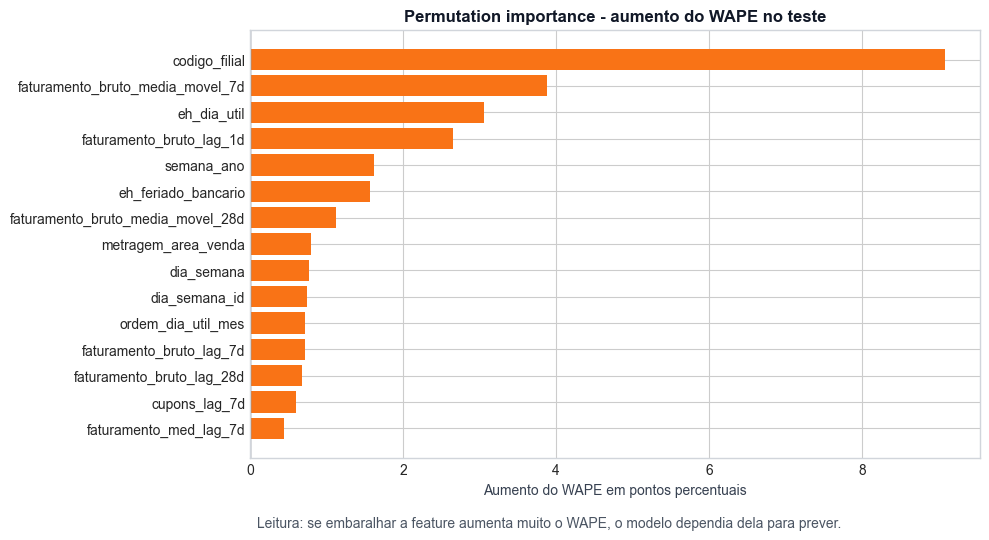

**Insight da permutation importance**  
`codigo_filial` foi a variável mais sensível: ao embaralhá-la, o WAPE subiu 9,09 p,p,.

In [6]:
def permutation_importance_wape(modelo, X_ref, y_real, features, n_repeats=3, random_state=42):
    rng = np.random.default_rng(random_state)
    pred_base = predizer_lightgbm(modelo, X_ref)
    wape_base = wape(y_real, pred_base)
    linhas = []

    for feature in features:
        valores = []
        for repeticao in range(n_repeats):
            X_perm = X_ref.copy()
            embaralhado = X_perm[feature].to_numpy(copy=True)
            rng.shuffle(embaralhado)
            X_perm[feature] = embaralhado
            pred_perm = predizer_lightgbm(modelo, X_perm)
            valores.append(wape(y_real, pred_perm))

        valores = np.array(valores, dtype=float)
        linhas.append({
            "feature": feature,
            "wape_base": wape_base,
            "wape_permutado_medio": valores.mean(),
            "wape_permutado_std": valores.std(),
            "delta_wape": valores.mean() - wape_base,
            "delta_wape_pp": (valores.mean() - wape_base) * 100,
            "n_repeats": n_repeats,
        })

    return pd.DataFrame(linhas).sort_values("delta_wape", ascending=False).reset_index(drop=True)


importancia_permutation = permutation_importance_wape(
    lightgbm_model,
    X_test,
    y_test_real,
    FEATURES_MODELO,
    n_repeats=N_REPEATS_PERMUTATION,
    random_state=RANDOM_STATE,
)

importancia_permutation.to_parquet(ARQUIVO_PERMUTATION, index=False)
display(importancia_permutation.head(20))

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = importancia_permutation.head(15).sort_values("delta_wape_pp")
ax.barh(plot_df["feature"], plot_df["delta_wape_pp"], color=PALETA["laranja"])
ax.set_title("Permutation importance - aumento do WAPE no teste")
ax.set_xlabel("Aumento do WAPE em pontos percentuais")
ax.set_ylabel("")
ax.axvline(0, color=PALETA["cinza"], linewidth=1)
ax.text(
    0.01,
    -0.16,
    "Leitura: se embaralhar a feature aumenta muito o WAPE, o modelo dependia dela para prever.",
    transform=ax.transAxes,
    color=PALETA["cinza"],
)
plt.tight_layout()
plt.show()

top_perm = importancia_permutation.iloc[0]
mostrar_insight(
    "Insight da permutation importance",
    f"`{top_perm['feature']}` foi a variável mais sensível: ao embaralhá-la, o WAPE subiu {formatar_pp(top_perm['delta_wape_pp'])}."
)

## 6. Importância por grupo de features

Aqui embaralhamos blocos inteiros de features. Isso ajuda a responder se o modelo depende mais de calendário, cadastro, lags ou médias móveis.

,grupo_feature,qtd_features,features,wape_base,wape_permutado_medio,delta_wape,delta_wape_pp
0,cadastro da filial,14,"codigo_filial, dia_semana, faixa_vida, localid...",0.195539,0.301386,0.105847,10.584708
1,calendário,21,"ano, mes, dia_mes, semana_mes, semana_ano, dia...",0.195539,0.288171,0.092632,9.263224
2,lags,9,"faturamento_bruto_lag_1d, faturamento_bruto_la...",0.195539,0.262773,0.067234,6.723374
3,médias móveis,8,"faturamento_bruto_media_movel_7d, faturamento_...",0.195539,0.254157,0.058617,5.861729


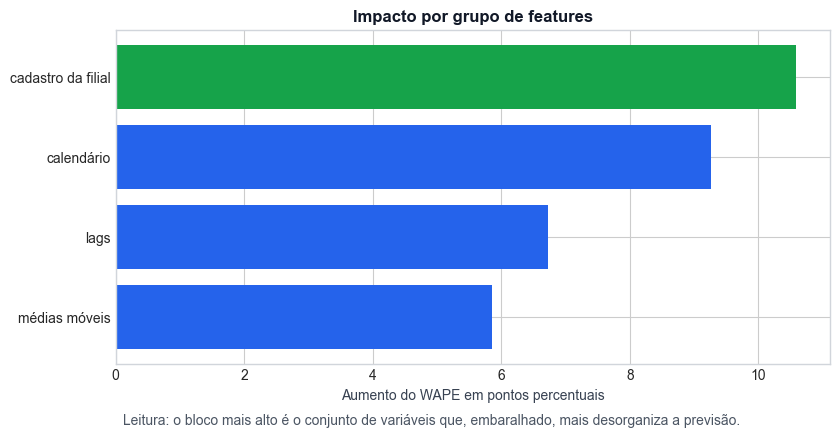

**Insight por grupo**  
O grupo `cadastro da filial` foi o mais importante no teste, elevando o WAPE em 10,58 p,p, quando embaralhado.

In [7]:
def classificar_feature(feature):
    if "lag_" in feature:
        return "lags"
    if any(padrao in feature for padrao in ["media_movel", "std_movel"]):
        return "médias móveis"
    if feature in FEATURES_CATEGORICAS or feature in ["metragem_area_venda", "idade_filial_meses", "idade_filial"]:
        return "cadastro da filial"
    if feature in [
        "ano", "mes", "dia_mes", "semana_mes", "semana_ano", "dia_semana_id", "trimestre", "semestre",
        "eh_semana_5", "fim_semana_id", "eh_feriado_bancario", "eh_dia_util", "ordem_dia_util_mes",
        "dias_uteis_no_mes", "eh_primeiro_dia_util_mes", "eh_quinto_dia_util_mes", "eh_inicio_mes",
        "eh_fim_mes", "dias_no_mes", "periodo_ordem", "dias_desde_primeira_venda",
    ]:
        return "calendário"
    return "outros"


GRUPOS_FEATURES = {}
for feature in FEATURES_MODELO:
    GRUPOS_FEATURES.setdefault(classificar_feature(feature), []).append(feature)


def permutation_importance_grupos(modelo, X_ref, y_real, grupos, n_repeats=3, random_state=42):
    rng = np.random.default_rng(random_state)
    pred_base = predizer_lightgbm(modelo, X_ref)
    wape_base = wape(y_real, pred_base)
    linhas = []

    for grupo, features in grupos.items():
        valores = []
        for repeticao in range(n_repeats):
            X_perm = X_ref.copy()
            for feature in features:
                embaralhado = X_perm[feature].to_numpy(copy=True)
                rng.shuffle(embaralhado)
                X_perm[feature] = embaralhado
            pred_perm = predizer_lightgbm(modelo, X_perm)
            valores.append(wape(y_real, pred_perm))

        valores = np.array(valores, dtype=float)
        linhas.append({
            "grupo_feature": grupo,
            "qtd_features": len(features),
            "features": ", ".join(features),
            "wape_base": wape_base,
            "wape_permutado_medio": valores.mean(),
            "delta_wape": valores.mean() - wape_base,
            "delta_wape_pp": (valores.mean() - wape_base) * 100,
        })

    return pd.DataFrame(linhas).sort_values("delta_wape", ascending=False).reset_index(drop=True)


importancia_grupos = permutation_importance_grupos(
    lightgbm_model,
    X_test,
    y_test_real,
    GRUPOS_FEATURES,
    n_repeats=N_REPEATS_PERMUTATION,
    random_state=RANDOM_STATE,
)

importancia_grupos.to_parquet(ARQUIVO_GRUPOS, index=False)
display(importancia_grupos)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
plot_df = importancia_grupos.sort_values("delta_wape_pp")
cores = [PALETA["verde"] if v == plot_df["delta_wape_pp"].max() else PALETA["azul"] for v in plot_df["delta_wape_pp"]]
ax.barh(plot_df["grupo_feature"], plot_df["delta_wape_pp"], color=cores)
ax.set_title("Impacto por grupo de features")
ax.set_xlabel("Aumento do WAPE em pontos percentuais")
ax.set_ylabel("")
ax.text(
    0.01,
    -0.18,
    "Leitura: o bloco mais alto é o conjunto de variáveis que, embaralhado, mais desorganiza a previsão.",
    transform=ax.transAxes,
    color=PALETA["cinza"],
)
plt.tight_layout()
plt.show()

top_grupo = importancia_grupos.iloc[0]
mostrar_insight(
    "Insight por grupo",
    f"O grupo `{top_grupo['grupo_feature']}` foi o mais importante no teste, elevando o WAPE em {formatar_pp(top_grupo['delta_wape_pp'])} quando embaralhado."
)

## 7. SHAP

O SHAP estima o impacto médio absoluto de cada feature na previsão. Diferente da importância nativa, ele ajuda a explicar a contribuição das variáveis nas previsões feitas pelo modelo.

,feature,mean_abs_shap,status,erro
0,faturamento_med_lag_7d,0.135697,ok,
1,codigo_filial,0.130865,ok,
2,eh_dia_util,0.113858,ok,
3,faturamento_bruto_media_movel_7d,0.083932,ok,
4,dia_semana_id,0.066478,ok,
5,eh_feriado_bancario,0.056748,ok,
6,faturamento_bruto_lag_28d,0.045959,ok,
7,faturamento_bruto_lag_1d,0.045672,ok,
8,faturamento_bruto_lag_7d,0.041757,ok,
9,semana_ano,0.040018,ok,


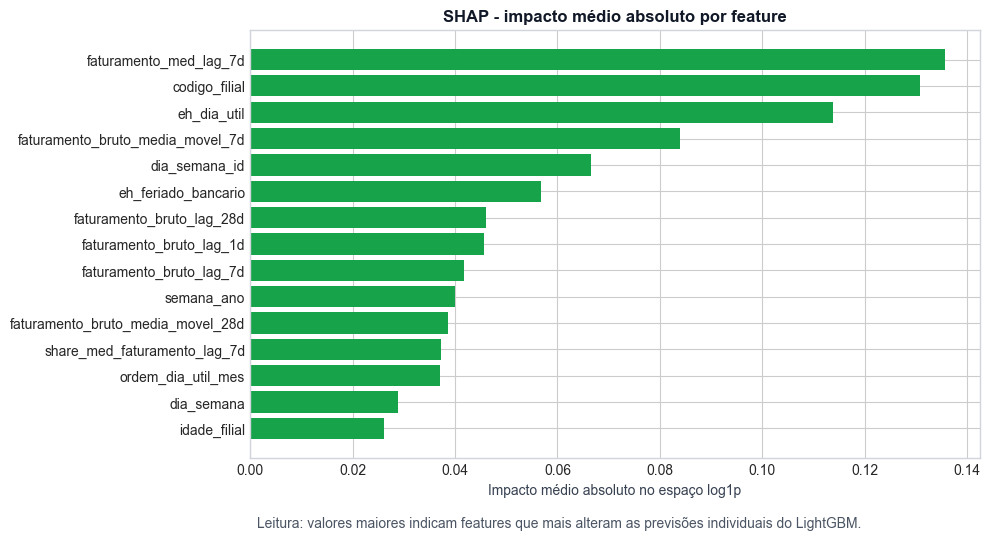

**Insight SHAP**  
`faturamento_med_lag_7d` teve o maior impacto médio absoluto nas previsões da amostra de teste.

In [8]:
try:
    import shap

    amostra = X_test.sample(min(AMOSTRA_SHAP, len(X_test)), random_state=RANDOM_STATE)
    amostra_lgb = preparar_lightgbm(amostra)

    explainer = shap.TreeExplainer(lightgbm_model.booster_)
    shap_values = explainer.shap_values(amostra_lgb)
    shap_array = np.asarray(shap_values)

    importancia_shap = pd.DataFrame({
        "feature": amostra.columns,
        "mean_abs_shap": np.abs(shap_array).mean(axis=0),
        "status": "ok",
        "erro": "",
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    importancia_shap.to_parquet(ARQUIVO_SHAP, index=False)
    display(importancia_shap.head(20))

    fig, ax = plt.subplots(figsize=(10, 5.5))
    plot_df = importancia_shap.head(15).sort_values("mean_abs_shap")
    ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color=PALETA["verde"])
    ax.set_title("SHAP - impacto médio absoluto por feature")
    ax.set_xlabel("Impacto médio absoluto no espaço log1p")
    ax.set_ylabel("")
    ax.text(
        0.01,
        -0.16,
        "Leitura: valores maiores indicam features que mais alteram as previsões individuais do LightGBM.",
        transform=ax.transAxes,
        color=PALETA["cinza"],
    )
    plt.tight_layout()
    plt.show()

    top_shap = importancia_shap.iloc[0]
    mostrar_insight(
        "Insight SHAP",
        f"`{top_shap['feature']}` teve o maior impacto médio absoluto nas previsões da amostra de teste."
    )

except Exception as exc:
    importancia_shap = pd.DataFrame([{
        "feature": "",
        "mean_abs_shap": np.nan,
        "status": "erro",
        "erro": str(exc),
    }])
    importancia_shap.to_parquet(ARQUIVO_SHAP, index=False)
    display(importancia_shap)
    mostrar_insight(
        "SHAP não executado",
        "O notebook continuou normalmente e registrou o erro no arquivo de saída. Verifique a instalação do pacote `shap` e compatibilidade com o ambiente."
    )

## 8. Experimento mensal replicável

Este experimento treina modelos simples usando janelas de 2024 e testa em meses específicos de 2025.

Cenários:

- `mesmo_mes_2024`: usa apenas o mesmo mês do ano anterior;
- `acumulado_2024_ate_mes`: usa janeiro até o mês-alvo de 2024;
- `janela_3m_2024`: usa o mês-alvo e até dois meses anteriores de 2024;
- `ano_2024_completo`: usa todo o ano de 2024.

Para isolar melhor o efeito das janelas históricas, removemos lags e médias móveis da lista de features deste diagnóstico. Assim o teste fica menos dependente de informações recentes do próprio período previsto.

In [9]:
PADROES_DINAMICOS = ["lag_", "media_movel", "std_movel"]
FEATURES_JANELAS_MENSAIS = [
    feature for feature in FEATURES_MODELO
    if not any(padrao in feature for padrao in PADROES_DINAMICOS)
]
CATEGORICAS_JANELAS = [feature for feature in FEATURES_CATEGORICAS if feature in FEATURES_JANELAS_MENSAIS]

display(pd.DataFrame({
    "grupo": ["features do modelo original", "features para janelas mensais", "categóricas nas janelas"],
    "qtd": [len(FEATURES_MODELO), len(FEATURES_JANELAS_MENSAIS), len(CATEGORICAS_JANELAS)],
}))


def preparar_lightgbm_janelas(X):
    X_lgb = X.copy()
    for coluna in CATEGORICAS_JANELAS:
        X_lgb[coluna] = X_lgb[coluna].astype("category")
    return X_lgb


def predizer_lightgbm_janelas(modelo, X):
    return desfazer_log(modelo.predict(preparar_lightgbm_janelas(X)))


def cenarios_para_mes(mes):
    return {
        "mesmo_mes_2024": [mes],
        "acumulado_2024_ate_mes": list(range(1, mes + 1)),
        "janela_3m_2024": list(range(max(1, mes - 2), mes + 1)),
        "ano_2024_completo": list(range(1, 13)),
    }


def treinar_avaliar_janela_mensal(mes_alvo, nome_cenario, meses_treino):
    df_treino = base[(base["ano_data"].eq(2024)) & (base["mes"].isin(meses_treino))].copy()
    df_teste = base[(base["ano_data"].eq(2025)) & (base["mes"].eq(mes_alvo))].copy()

    X_tr = df_treino[FEATURES_JANELAS_MENSAIS].copy()
    y_tr = df_treino[TARGET_TRANSFORMADO]
    X_te = df_teste[FEATURES_JANELAS_MENSAIS].copy()

    modelo = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=15,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

    modelo.fit(
        preparar_lightgbm_janelas(X_tr),
        y_tr,
        categorical_feature=CATEGORICAS_JANELAS,
    )

    pred = predizer_lightgbm_janelas(modelo, X_te)

    metrica = calcular_metricas(
        df_teste[ALVO],
        pred,
        "lightgbm_janela_mensal",
        "teste_mensal",
        extra={
            "mes_alvo": mes_alvo,
            "cenario": nome_cenario,
            "meses_treino_2024": ",".join(f"{m:02d}" for m in meses_treino),
            "qtd_meses_treino": len(meses_treino),
            "linhas_treino": len(df_treino),
        },
    )

    predicoes = df_teste[["codigo_filial", "data", ALVO]].copy()
    predicoes["mes_alvo"] = mes_alvo
    predicoes["cenario"] = nome_cenario
    predicoes["meses_treino_2024"] = ",".join(f"{m:02d}" for m in meses_treino)
    predicoes["predito"] = pred

    return metrica, predicoes


metricas_mensais = []
predicoes_mensais = []

for mes_alvo in range(1, 13):
    for nome_cenario, meses_treino in cenarios_para_mes(mes_alvo).items():
        metrica, predicoes = treinar_avaliar_janela_mensal(mes_alvo, nome_cenario, meses_treino)
        metricas_mensais.append(metrica)
        predicoes_mensais.append(predicoes)

metricas_janelas_mensais = pd.DataFrame(metricas_mensais).sort_values(["mes_alvo", "wape"]).reset_index(drop=True)
predicoes_janelas_mensais = pd.concat(predicoes_mensais, ignore_index=True)

metricas_janelas_mensais.to_parquet(ARQUIVO_METRICAS_MESES, index=False)
predicoes_janelas_mensais.to_parquet(ARQUIVO_PREDICOES_MESES, index=False)

display(metricas_janelas_mensais.head(20))

,grupo,qtd
0,features do modelo original,52
1,features para janelas mensais,35
2,categóricas nas janelas,12


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


...

C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,modelo,conjunto,linhas,mae,rmse,wape,bias_pct,faturamento_real,faturamento_previsto,mes_alvo,cenario,meses_treino_2024,qtd_meses_treino,linhas_treino
0,lightgbm_janela_mensal,teste_mensal,3100,13711.886121,25442.620172,0.203046,-0.105955,2.093456e+08,1.871644e+08,1,ano_2024_completo,"01,02,03,04,05,06,07,08,09,10,11,12",12,36582
1,lightgbm_janela_mensal,teste_mensal,3100,13830.281553,24911.164618,0.204799,-0.134784,2.093456e+08,1.811293e+08,1,mesmo_mes_2024,01,1,3082
2,lightgbm_janela_mensal,teste_mensal,3100,13830.281553,24911.164618,0.204799,-0.134784,2.093456e+08,1.811293e+08,1,acumulado_2024_ate_mes,01,1,3082
3,lightgbm_janela_mensal,teste_mensal,3100,13830.281553,24911.164618,0.204799,-0.134784,2.093456e+08,1.811293e+08,1,janela_3m_2024,01,1,3082
4,lightgbm_janela_mensal,teste_mensal,2800,16485.240178,31554.476386,0.214066,-0.110947,2.156282e+08,1.917048e+08,2,acumulado_2024_ate_mes,"01,02",2,5982
5,lightgbm_janela_mensal,teste_mensal,2800,16485.240178,31554.476386,0.214066,-0.110947,2.156282e+08,1.917048e+08,2,janela_3m_2024,"01,02",2,5982
6,lightgbm_janela_mensal,teste_mensal,2800,16543.435858,32592.061925,0.214822,-0.130015,2.156282e+08,1.875932e+08,2,mesmo_mes_2024,02,1,2900
7,lightgbm_janela_mensal,teste_mensal,2800,17158.914682,34009.160934,0.222814,-0.145060,2.156282e+08,1.843490e+08,2,ano_2024_completo,"01,02,03,04,05,06,07,08,09,10,11,12",12,36582
8,lightgbm_janela_mensal,teste_mensal,3100,19729.294973,34812.124404,0.250760,0.013793,2.439018e+08,2.472660e+08,3,acumulado_2024_ate_mes,"01,02,03",3,9082
9,lightgbm_janela_mensal,teste_mensal,3100,19729.294973,34812.124404,0.250760,0.013793,2.439018e+08,2.472660e+08,3,janela_3m_2024,"01,02,03",3,9082


## 9. Leitura dos resultados mensais

A tabela abaixo mostra o melhor cenário para cada mês de 2025. Depois olhamos a média de desempenho por cenário.

,mes_alvo,cenario,meses_treino_2024,wape,mae,bias_pct,linhas_treino
0,1,ano_2024_completo,"01,02,03,04,05,06,07,08,09,10,11,12",0.203046,13711.886121,-0.105955,36582
1,2,acumulado_2024_ate_mes,"01,02",0.214066,16485.240178,-0.110947,5982
2,3,acumulado_2024_ate_mes,"01,02,03",0.250760,19729.294973,0.013793,9082
3,4,acumulado_2024_ate_mes,"01,02,03,04",0.183314,13304.962816,-0.012672,12082
4,5,mesmo_mes_2024,05,0.232118,19040.222932,-0.177604,3100
5,6,ano_2024_completo,"01,02,03,04,05,06,07,08,09,10,11,12",0.234898,19019.208053,-0.133907,36582
6,7,mesmo_mes_2024,07,0.207257,16926.081837,-0.111758,3100
7,8,acumulado_2024_ate_mes,"01,02,03,04,05,06,07,08",0.185889,15861.827325,-0.105995,24382
8,9,acumulado_2024_ate_mes,"01,02,03,04,05,06,07,08,09",0.208934,17572.973381,-0.126609,27382
9,10,acumulado_2024_ate_mes,"01,02,03,04,05,06,07,08,09,10",0.218321,18376.867630,-0.069779,30482


,cenario,wape_medio,wape_mediano,mae_medio,bias_medio,vezes_melhor
0,mesmo_mes_2024,0.233236,0.224026,19034.136901,-0.103013,4
1,acumulado_2024_ate_mes,0.235383,0.216194,19277.813547,-0.088195,6
2,janela_3m_2024,0.240055,0.231572,19684.828579,-0.098919,0
3,ano_2024_completo,0.243546,0.244002,19965.428686,-0.166764,2


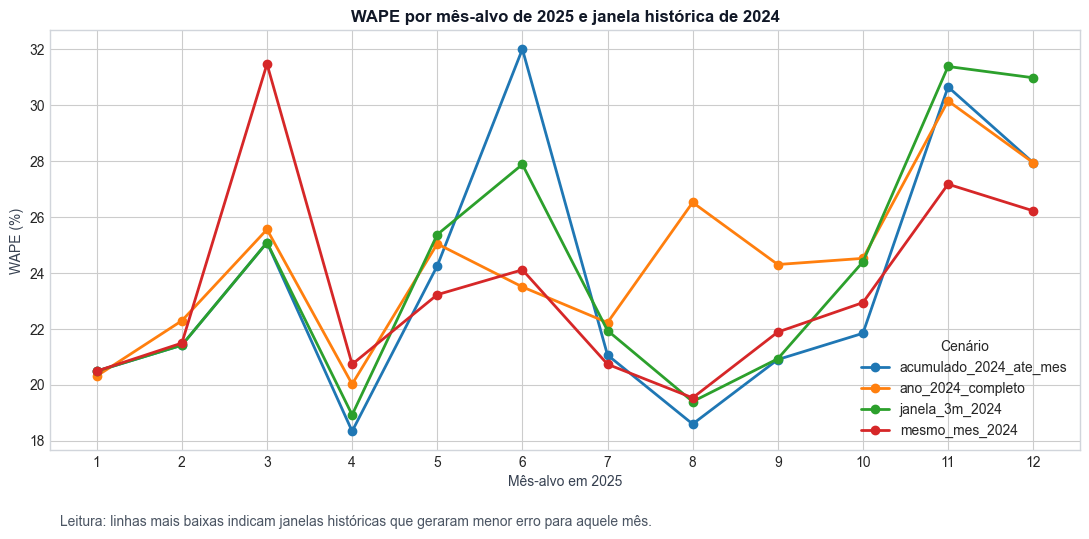

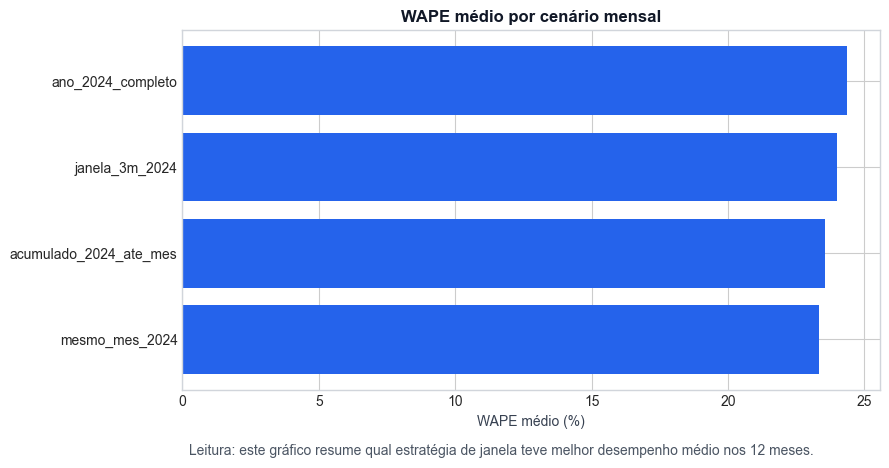

**Insight das janelas mensais**  
O menor WAPE médio veio de `mesmo_mes_2024` (23,32%). O cenário que mais venceu mês a mês foi `acumulado_2024_ate_mes`.

In [10]:
melhor_por_mes = (
    metricas_janelas_mensais
    .sort_values(["mes_alvo", "wape", "mae"])
    .groupby("mes_alvo", as_index=False)
    .first()
)

resumo_cenario = (
    metricas_janelas_mensais
    .groupby("cenario", as_index=False)
    .agg(
        wape_medio=("wape", "mean"),
        wape_mediano=("wape", "median"),
        mae_medio=("mae", "mean"),
        bias_medio=("bias_pct", "mean"),
    )
    .sort_values("wape_medio")
)

vitorias = melhor_por_mes["cenario"].value_counts().rename_axis("cenario").reset_index(name="vezes_melhor")
resumo_cenario = resumo_cenario.merge(vitorias, on="cenario", how="left")
resumo_cenario["vezes_melhor"] = resumo_cenario["vezes_melhor"].fillna(0).astype(int)

display(melhor_por_mes[["mes_alvo", "cenario", "meses_treino_2024", "wape", "mae", "bias_pct", "linhas_treino"]])
display(resumo_cenario)

fig, ax = plt.subplots(figsize=(11, 5.5))
for cenario, grupo in metricas_janelas_mensais.groupby("cenario"):
    grupo = grupo.sort_values("mes_alvo")
    ax.plot(grupo["mes_alvo"], grupo["wape"] * 100, marker="o", linewidth=2, label=cenario)

ax.set_title("WAPE por mês-alvo de 2025 e janela histórica de 2024")
ax.set_xlabel("Mês-alvo em 2025")
ax.set_ylabel("WAPE (%)")
ax.set_xticks(range(1, 13))
ax.legend(title="Cenário", loc="best")
ax.text(
    0.01,
    -0.18,
    "Leitura: linhas mais baixas indicam janelas históricas que geraram menor erro para aquele mês.",
    transform=ax.transAxes,
    color=PALETA["cinza"],
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = resumo_cenario.sort_values("wape_medio", ascending=True)
ax.barh(plot_df["cenario"], plot_df["wape_medio"] * 100, color=PALETA["azul"])
ax.set_title("WAPE médio por cenário mensal")
ax.set_xlabel("WAPE médio (%)")
ax.set_ylabel("")
ax.text(
    0.01,
    -0.18,
    "Leitura: este gráfico resume qual estratégia de janela teve melhor desempenho médio nos 12 meses.",
    transform=ax.transAxes,
    color=PALETA["cinza"],
)
plt.tight_layout()
plt.show()

melhor_cenario_medio = resumo_cenario.iloc[0]
vencedor_mes = melhor_por_mes["cenario"].value_counts().idxmax()
mostrar_insight(
    "Insight das janelas mensais",
    f"O menor WAPE médio veio de `{melhor_cenario_medio['cenario']}` ({formatar_pct(melhor_cenario_medio['wape_medio'])}). "
    f"O cenário que mais venceu mês a mês foi `{vencedor_mes}`."
)

## 10. Arquivos gerados

In [11]:
arquivos_gerados = pd.Series({
    "permutation_importance": str(ARQUIVO_PERMUTATION),
    "importancia_grupos": str(ARQUIVO_GRUPOS),
    "importancia_shap": str(ARQUIVO_SHAP),
    "metricas_janelas_mensais": str(ARQUIVO_METRICAS_MESES),
    "predicoes_janelas_mensais": str(ARQUIVO_PREDICOES_MESES),
}).to_frame("arquivo")

display(arquivos_gerados)

,arquivo
permutation_importance,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\impo...
importancia_grupos,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\impo...
importancia_shap,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\impo...
metricas_janelas_mensais,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\metr...
predicoes_janelas_mensais,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\pred...
